# IEEE 123 Node

In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from unit_converter import UnitConverter
import fault
import fault1
import fault2
import locator
import locator1
import locator2
import locator3
from topologia import FeederTopology

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [3]:
DSS_FILE_REG = BASE_DIR / "data" / "123Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE_NO_REG = BASE_DIR / "data" / "123Bus" / "Run_IEEE123Bus_no_reg.dss"


## Medida SE, sem regulador

In [9]:
simulador = fault.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.40  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df1 = localizador.df.copy()


Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 1334/1334 [00:00<00:00, 2078.48it/s]


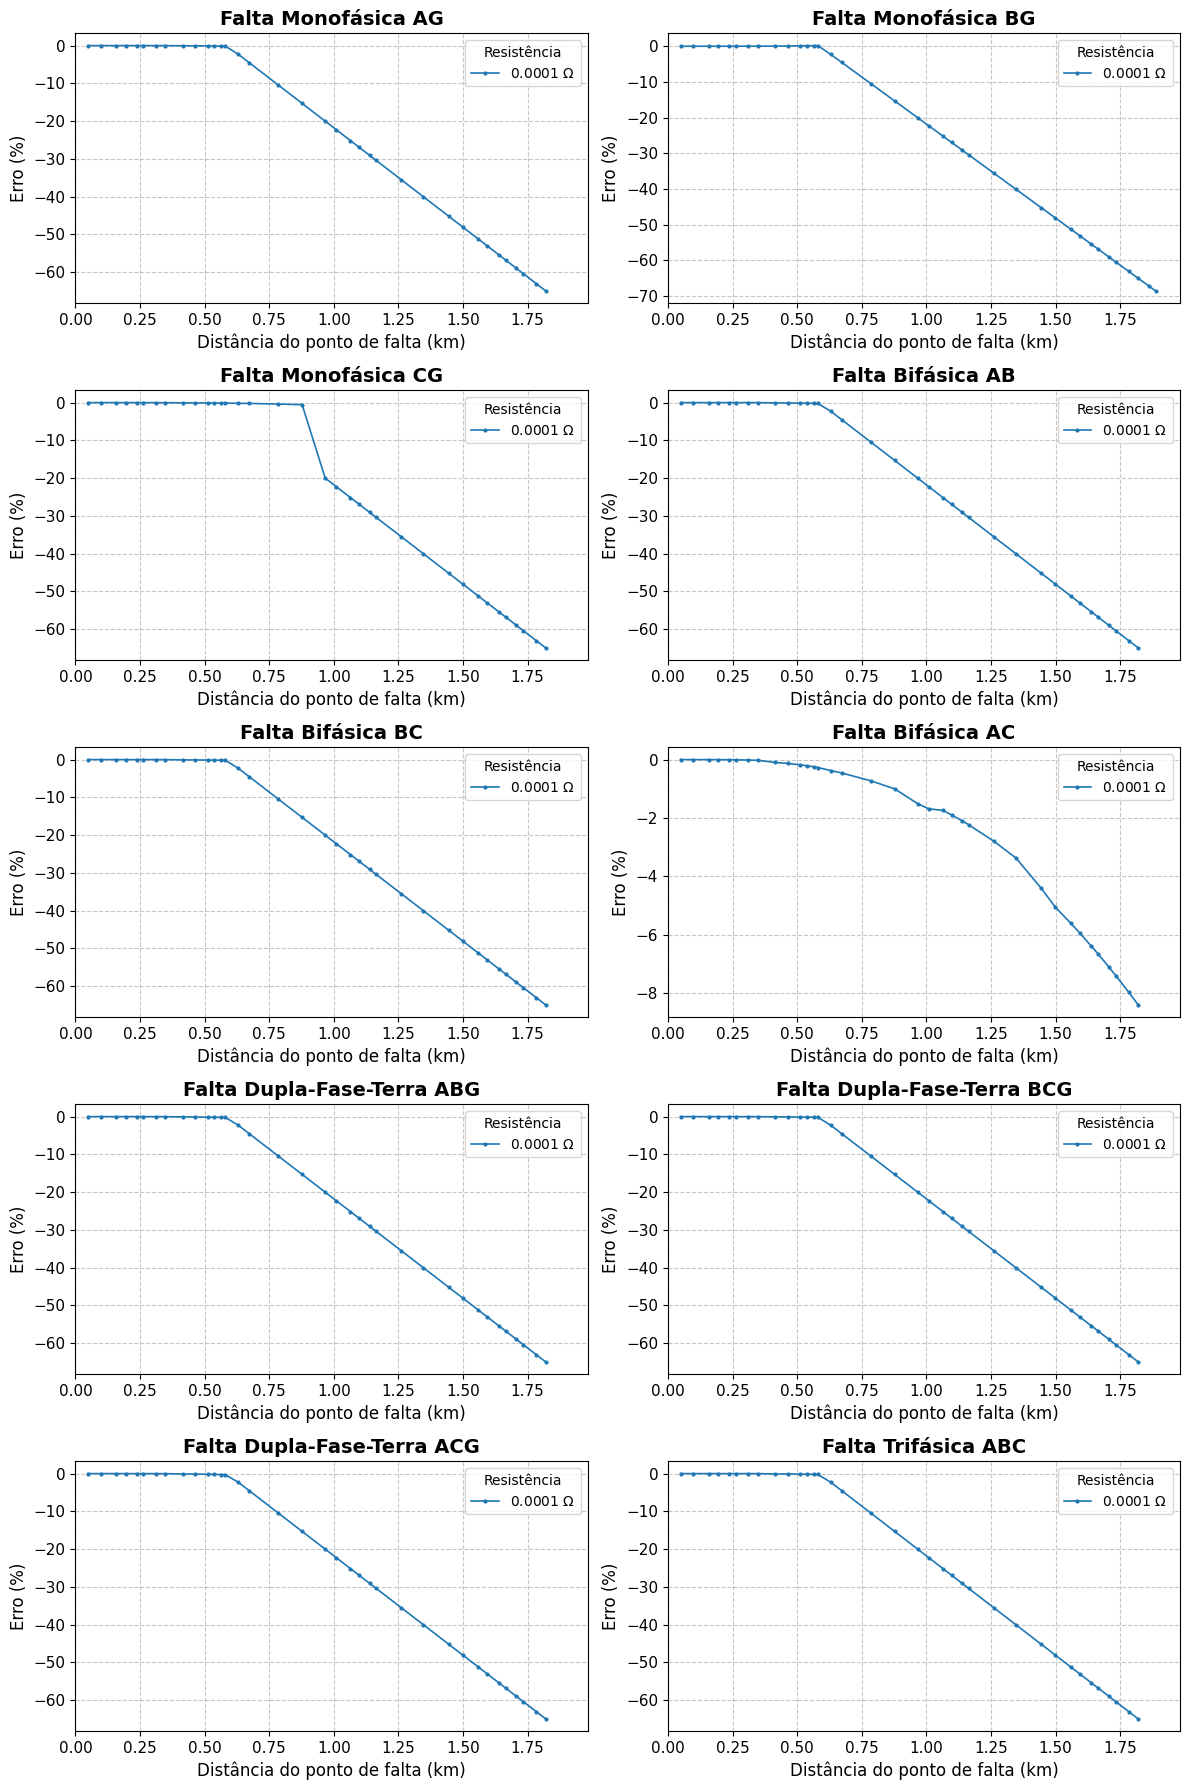

In [10]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = df1

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()

## Multiplas medidas, sem regulador

In [4]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.40  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df2 = localizador.df.copy()


Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 1334/1334 [45:13<00:00,  2.03s/it]


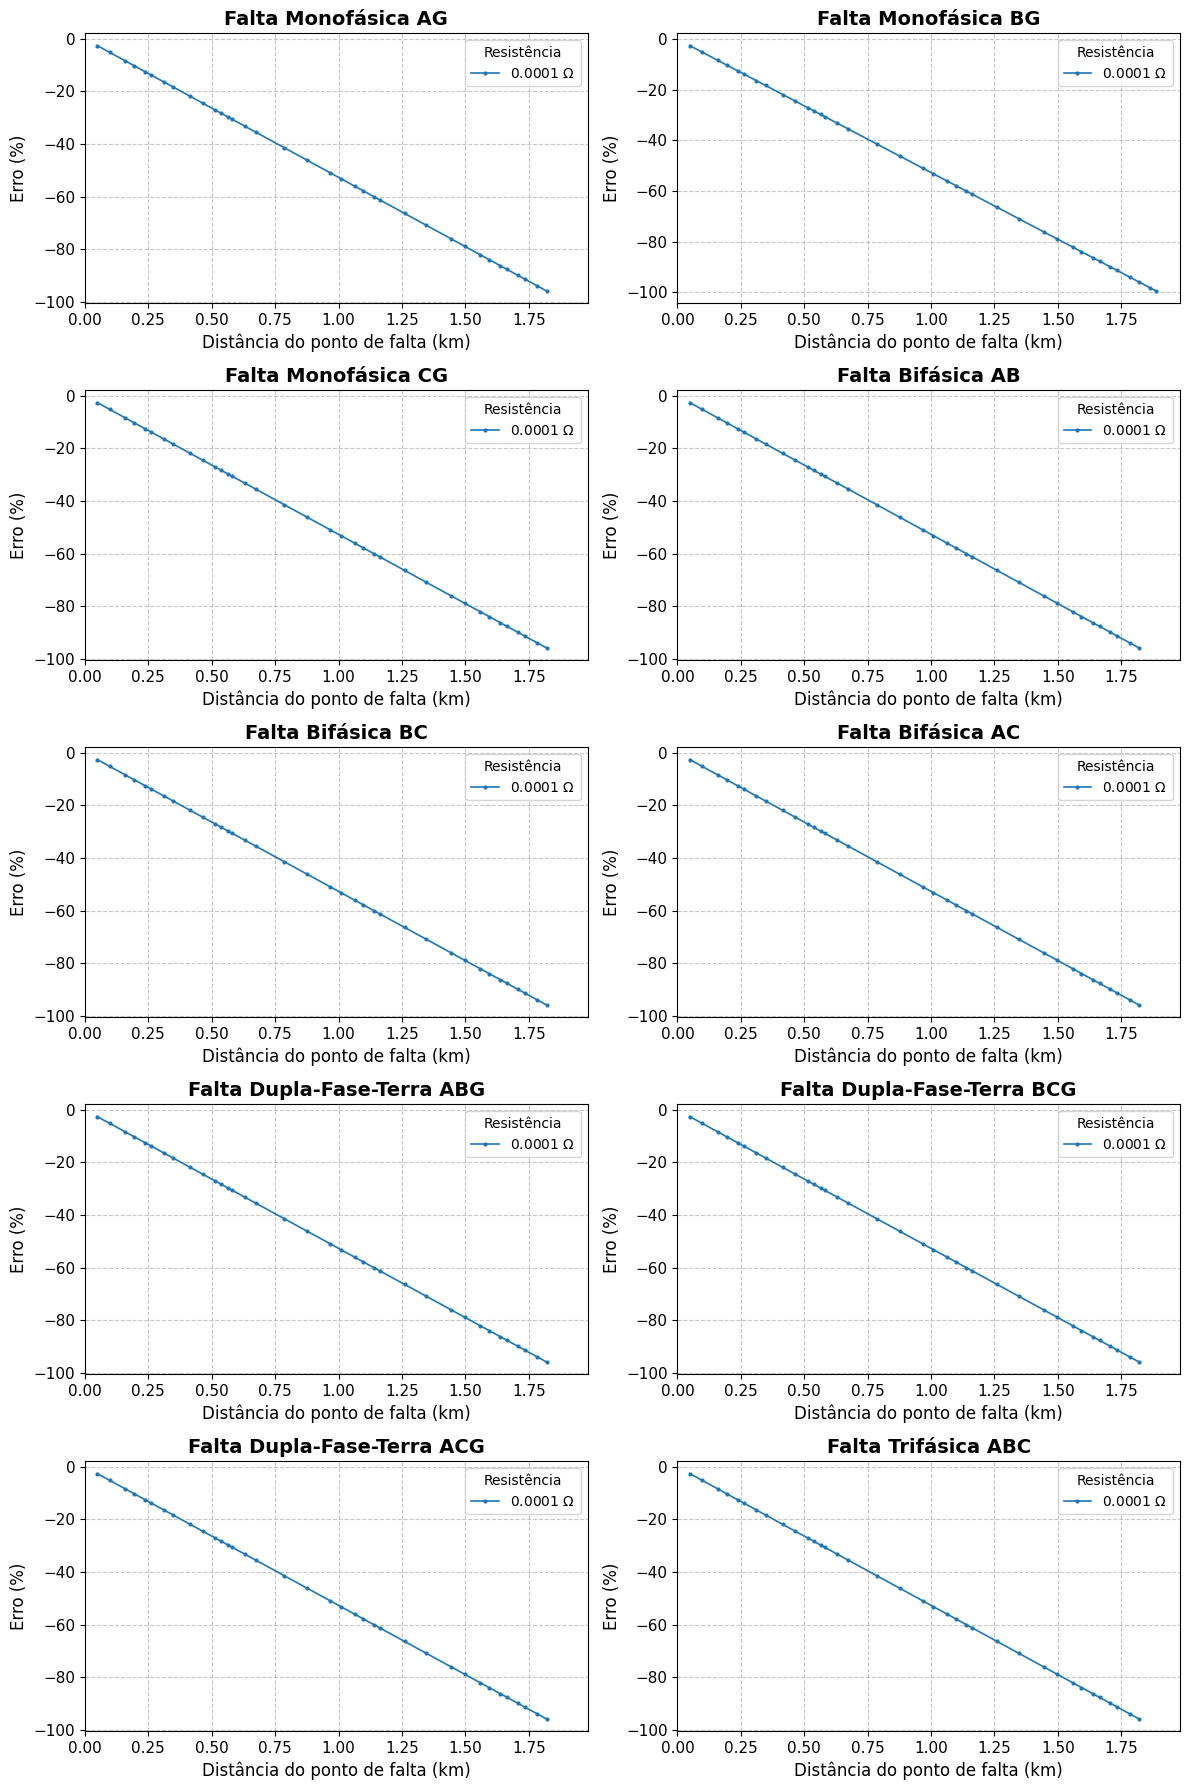

In [5]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

results_df = df2

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()